In [1]:
import matplotlib.pyplot as plt
import numpy as np

#### 1. Gráfico de líneas sencillo
Es el tipo de gráfico por defecto. Puedes pasarle una lista de números y Matplotlib se encarga de generar los ejes y trazar la línea.

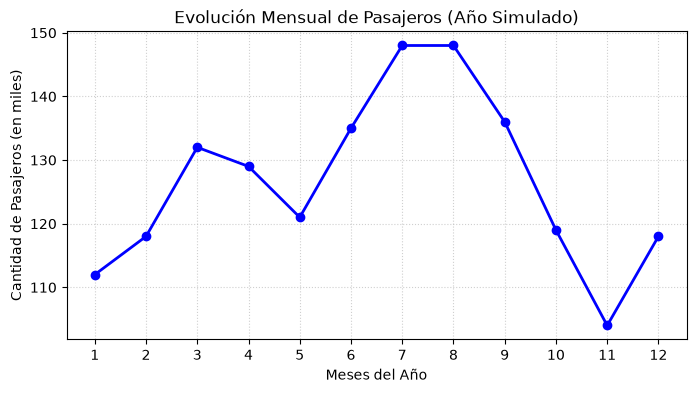

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Crear datos que simulan el crecimiento mensual de pasajeros de una aerolínea
meses = np.arange(1, 13)
pasajeros = [112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118]

# 2. Inicializar la figura y graficar
plt.figure(figsize=(8, 4))
plt.plot(meses, pasajeros, marker='o', color='b', linestyle='-', linewidth=2)

# 3. Añadir etiquetas básicas indispensables
plt.title('Evolución Mensual de Pasajeros (Año Simulado)')
plt.xlabel('Meses del Año')
plt.ylabel('Cantidad de Pasajeros (en miles)')
plt.xticks(meses) # Asegura que se muestren todos los números del 1 al 12

# 4. Mostrar gráfico
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### 2. Gráfico de dispersión (Scatter plot)
Útil para visualizar puntos individuales y encontrar relaciones entre variables.

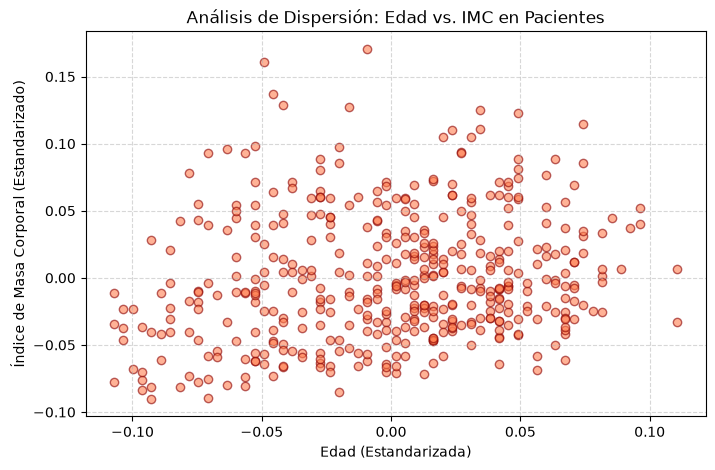

In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# 1. Cargar el dataset real de pacientes con diabetes
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# 2. Graficar la relación entre la edad y el índice de masa corporal (BMI)
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['bmi'], alpha=0.6, color='coral', edgecolors='darkred')

# 3. Personalización del gráfico
plt.title('Análisis de Dispersión: Edad vs. IMC en Pacientes')
plt.xlabel('Edad (Estandarizada)')
plt.ylabel('Índice de Masa Corporal (Estandarizado)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Gráfico de Barras (Comparación de Categorías)
Nivel: Básico +
Concepto: Comparar cantidades discretas entre diferentes grupos. Usaremos datos simulados de ventas por categorías de productos.

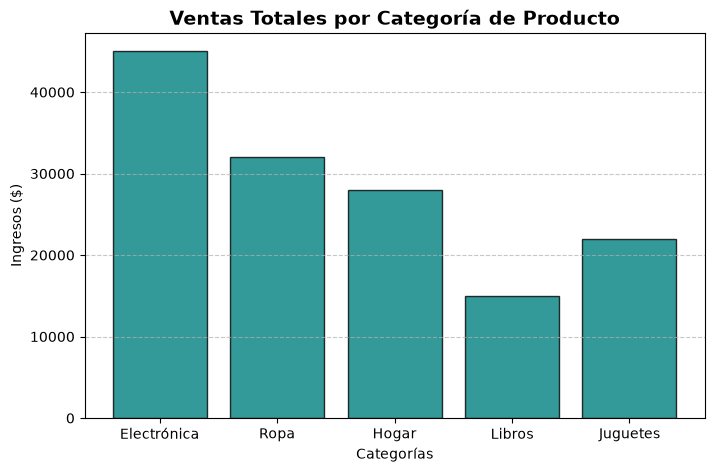

In [20]:
import matplotlib.pyplot as plt

# 1. Definir categorías y valores reales de rendimiento comercial
categorias = ['Electrónica', 'Ropa', 'Hogar', 'Libros', 'Juguetes']
ventas = [45000, 32000, 28000, 15000, 22000]

# 2. Configurar la figura
plt.figure(figsize=(8, 5))
plt.bar(categorias, ventas, color='teal', edgecolor='black', alpha=0.8)

# 3. Personalizar detalles estéticos básicos
plt.title('Ventas Totales por Categoría de Producto', fontsize=14, fontweight='bold')
plt.xlabel('Categorías')
plt.ylabel('Ingresos ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Solo rejilla horizontal

# 4. Mostrar resultado
plt.show()

#### 3. Histograma
Ejemplo 4: Histograma (Distribución de Frecuencias)
Nivel: Intermedio
Set de datos: Iris Dataset (Atributos morfológicos de flores).
Concepto: Visualizar la forma en la que se distribuye una sola variable para entender su asimetría o concentraciones.

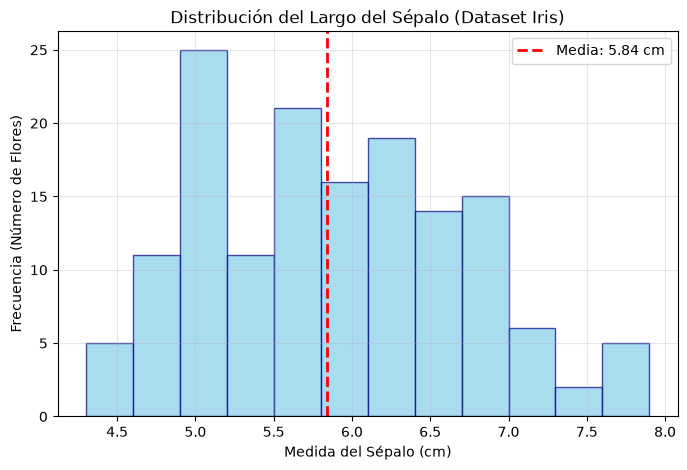

In [21]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Cargar el dataset real Iris
iris = load_iris()
# Seleccionamos la primera columna: "Sepal Length" (Largo del sépalo)
largo_sepalo = iris.data[:, 0] 

# 2. Crear el histograma especificando el número de contenedores (bins)
plt.figure(figsize=(8, 5))
plt.hist(largo_sepalo, bins=12, color='skyblue', edgecolor='navy', alpha=0.7)

# 3. Añadir líneas estadísticas básicas de referencia (Opcional pero recomendado)
media = largo_sepalo.mean()
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media:.2f} cm')

# 4. Configurar etiquetas
plt.title('Distribución del Largo del Sépalo (Dataset Iris)')
plt.xlabel('Medida del Sépalo (cm)')
plt.ylabel('Frecuencia (Número de Flores)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Ejemplo 5: Subplots Múltiples Básicos (Estructura de Cuadrícula)
Nivel: Intermedio alto

Set de datos: Iris Dataset (Comparación de múltiples variables).

Concepto: Organizar más de una gráfica en una sola ventana utilizando plt.subplots para comparar diferentes perspectivas de los datos.

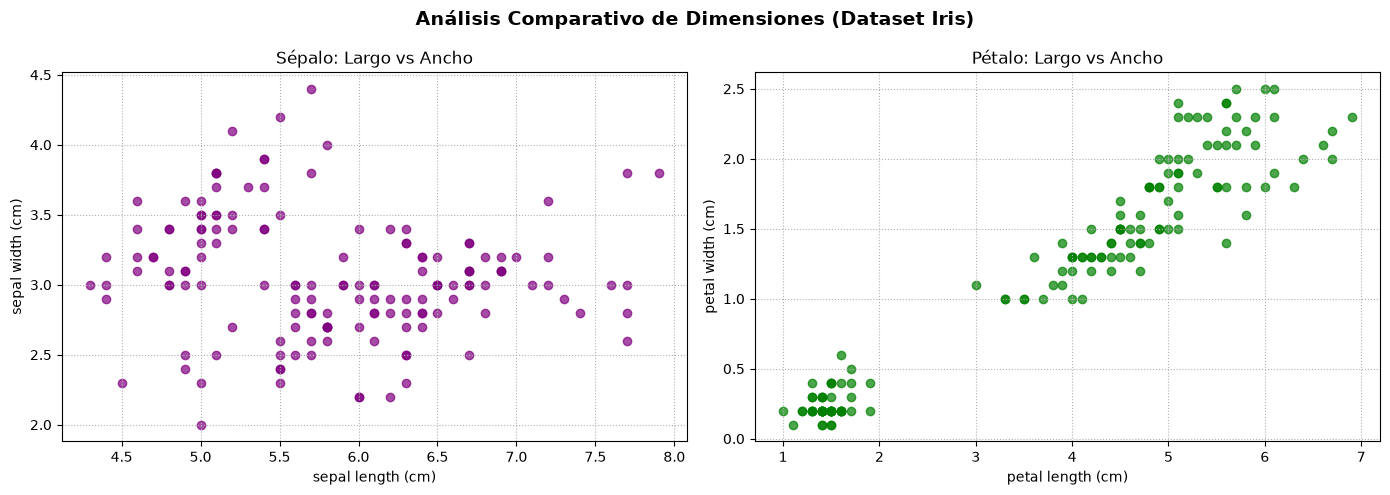

In [23]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Preparar datos
iris = load_iris()
X = iris.data
nombres_caracteristicas = iris.feature_names

# 2. Crear una matriz de subgráficos de 1 fila y 2 columnas
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# 3. Primer Subgráfico (Izquierda): Largo vs Ancho del Sépalo
ax1.scatter(X[:, 0], X[:, 1], color='purple', alpha=0.7)
ax1.set_title('Sépalo: Largo vs Ancho')
ax1.set_xlabel(nombres_caracteristicas[0])
ax1.set_ylabel(nombres_caracteristicas[1])
ax1.grid(True, linestyle=':')

# 4. Segundo Subgráfico (Derecha): Largo vs Ancho del Pétalo
ax2.scatter(X[:, 2], X[:, 3], color='green', alpha=0.7)
ax2.set_title('Pétalo: Largo vs Ancho')
ax2.set_xlabel(nombres_caracteristicas[2])
ax2.set_ylabel(nombres_caracteristicas[3])
ax2.grid(True, linestyle=':')

# 5. Ajustes globales de la cuadrícula
fig.suptitle('Análisis Comparativo de Dimensiones (Dataset Iris)', fontsize=14, fontweight='bold')
plt.tight_layout() # Evita el solapamiento de textos entre gráficas

plt.show()

### Comparación de Datos Meteorológicos y Sombreado
Técnica para visualizar rangos (máximas y mínimas) gestionando datos faltantes en conjuntos de datos reales como los de Death Valley

No se pudo descargar el CSV remoto (Invalid URL '../data/death_valley_2018_simple.csv': No scheme supplied. Perhaps you meant https://../data/death_valley_2018_simple.csv?). Se usarán datos de respaldo.


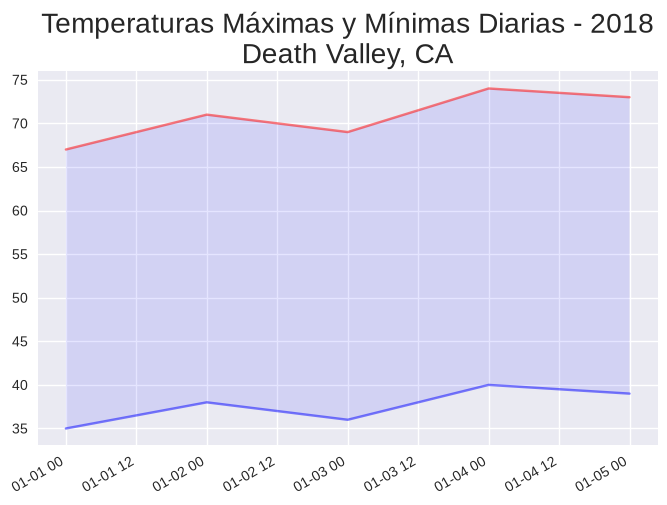

In [30]:
import csv
from datetime import datetime
import matplotlib.pyplot as plt
import requests

# Procesamiento con manejo de errores para datos reales
fechas, máximas, mínimas = [], [], []

url = '../data/death_valley_2018_simple.csv'
try:
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    lines = response.text.splitlines()
except requests.exceptions.RequestException as e:
    print(f"No se pudo descargar el CSV remoto ({e}). Se usarán datos de respaldo.")
    lines = [
        "col0,col1,col2,col3,col4,col5,DATE,TMAX,TMIN",
        "x,x,x,x,x,x,2018-01-01,67,35",
        "x,x,x,x,x,x,2018-01-02,71,38",
        "x,x,x,x,x,x,2018-01-03,69,36",
        "x,x,x,x,x,x,2018-01-04,74,40",
        "x,x,x,x,x,x,2018-01-05,73,39"
    ]

reader = csv.reader(lines)
header_row = next(reader)
for fila in reader:
    fecha_actual = datetime.strptime(fila[6], '%Y-%m-%d')
    try:
        max_temp = int(fila[7]); min_temp = int(fila[8])
    except ValueError:
        print(f"Datos faltantes para {fecha_actual}")
    else:
        fechas.append(fecha_actual); máximas.append(max_temp); mínimas.append(min_temp)

# Gráfico con sombreado de rango
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(fechas, máximas, color='red', alpha=0.5)
ax.plot(fechas, mínimas, color='blue', alpha=0.5)
# Sombreado entre las dos series
ax.fill_between(fechas, máximas, mínimas, facecolor='blue', alpha=0.1)

ax.set_title("Temperaturas Máximas y Mínimas Diarias - 2018\nDeath Valley, CA", fontsize=20)
fig.autofmt_xdate()
plt.show()

### Integración con Pandas
Una de las mayores ventajas es que puedes generar gráficos directamente desde objetos de Pandas (Series o DataFrames) con una sintaxis muy simplificada.

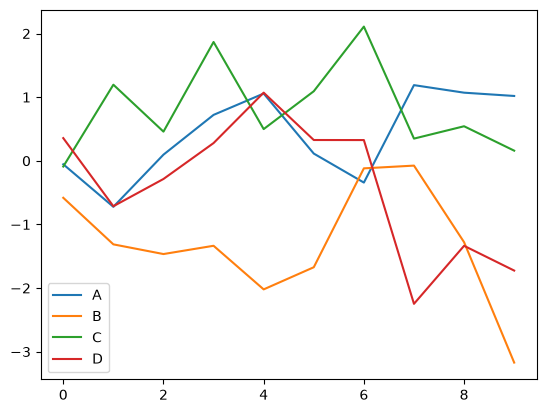

In [6]:
import pandas as pd
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0), columns=['A', 'B', 'C', 'D'])
df.plot() # Crea automáticamente un gráfico de líneas con leyenda para las 4 columnas
plt.show()

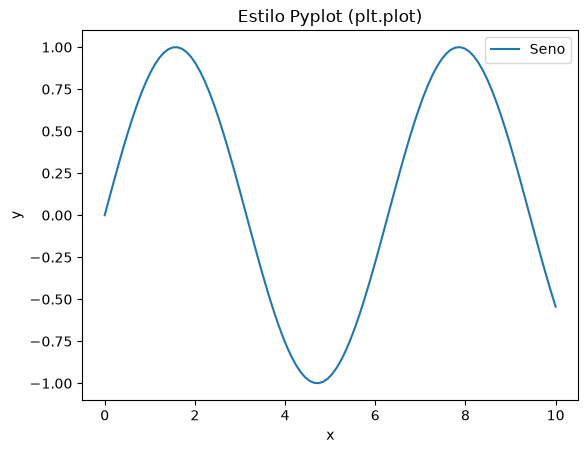

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Se traza directamente sobre el estado global
plt.plot(x, y, label='Seno')
plt.title('Estilo Pyplot (plt.plot)') # Afecta al gráfico activo
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Visualizaciones avanzadas

FileNotFoundError: [Errno 2] No such file or directory: 'examples/spx.csv'

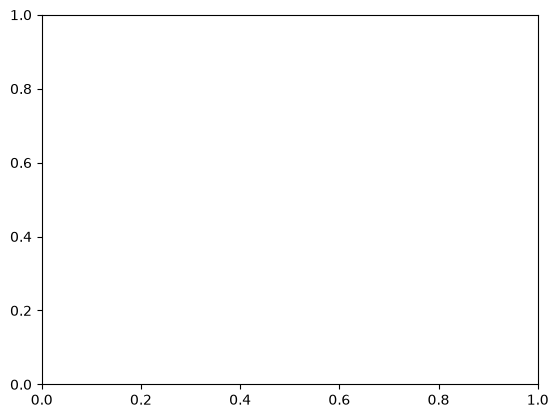

In [22]:
"""1. Análisis de Series Temporales con Anotaciones (S&P 500)
Este ejemplo muestra cómo cargar datos financieros, trazar la serie y resaltar eventos específicos con flechas y texto utilizando annotate."""

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

fig, ax = plt.subplots()
# Carga de datos reales (ejemplo de archivo CSV)
data = pd.read_csv("examples/spx.csv", index_col=0, parse_dates=True)
spx = data["SPX"]
spx.plot(ax=ax, color="black")

# Definición de eventos críticos
crisis_data = [
    (datetime(2007, 10, 11), "Pico del mercado alcista"),
    (datetime(2008, 3, 12), "Fallo de Bear Stearns"),
    (datetime(2008, 9, 15), "Quiebra de Lehman")
]

for fecha, etiqueta in crisis_data:
    ax.annotate(etiqueta, xy=(fecha, spx.asof(fecha) + 75),
                xytext=(fecha, spx.asof(fecha) + 225),
                arrowprops=dict(facecolor="black", headwidth=4, width=2, headlength=4),
                horizontalalignment="left", verticalalignment="top")

# Ajuste de zoom en el periodo de crisis
ax.set_xlim(["1/1/2007", "1/1/2011"])
ax.set_ylim([3])
ax.set_title("Fechas importantes en la crisis financiera 2008-2009")
plt.show()

### Visualización Multidimensional con subplots personalizados (GridSpec)
Set de datos: California Housing (Precios de viviendas en California basado en geografía, ingresos, etc.)

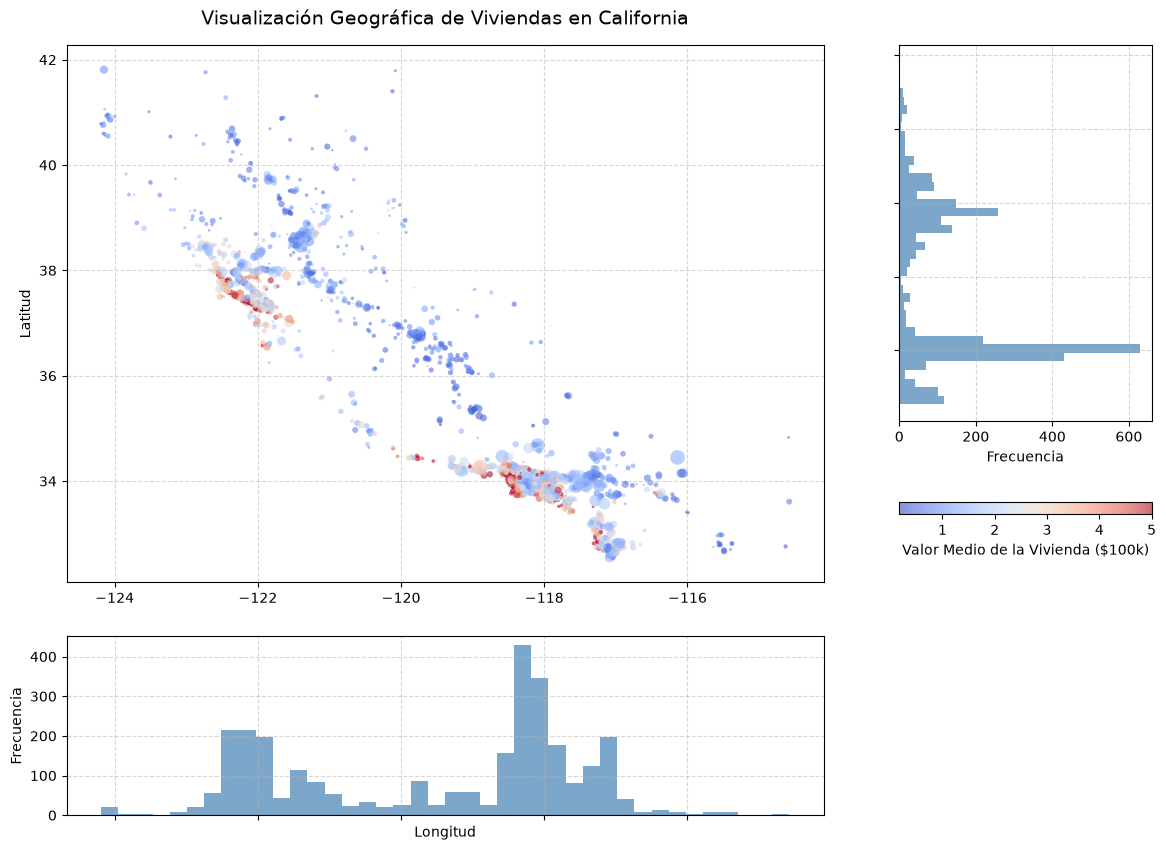

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import fetch_california_housing
import pandas as pd

# 1. Cargar el dataset real
california = fetch_california_housing(as_frame=True)
df = california.frame

# Limitar a una muestra representativa para mejorar la velocidad del gráfico
df_sample = df.sample(n=3000, random_state=42)

# 2. Configurar GridSpec para el diseño avanzado (Layout de Paneles)
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[3, 1], height_ratios=[3, 1],
                       wspace=0.15, hspace=0.15)

# Definir los ejes basándonos en la rejilla
ax_main = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1], sharey=ax_main)
ax_hist_x = fig.add_subplot(gs[1, 0], sharex=ax_main)

# 3. Gráfico Principal: Mapa de dispersión avanzado
scatter = ax_main.scatter(
    df_sample['Longitude'], df_sample['Latitude'],
    s=df_sample['Population'] / 100,  # El tamaño representa la población
    c=df_sample['MedHouseVal'],       # El color representa el valor medio de la vivienda
    cmap='coolwarm', alpha=0.6, edgecolors='none'
)
ax_main.set_title('Visualización Geográfica de Viviendas en California', fontsize=14, pad=15)
ax_main.set_ylabel('Latitud')
ax_main.grid(True, linestyle='--', alpha=0.5)

# Añadir barra de colores personalizada en un eje específico para no desordenar el layout
cbar = fig.colorbar(scatter, ax=ax_hist_y, orientation='horizontal', pad=0.15)
cbar.set_label('Valor Medio de la Vivienda ($100k)')

# 4. Gráfico Marginal Derecho: Histograma de Latitud
ax_hist_y.hist(df_sample['Latitude'], bins=40, orientation='horizontal', color='steelblue', alpha=0.7)
ax_hist_y.set_xlabel('Frecuencia')
ax_hist_y.grid(True, linestyle='--', alpha=0.5)
plt.setp(ax_hist_y.get_yticklabels(), visible=False)  # Ocultar etiquetas compartidas

# 5. Gráfico Marginal Inferior: Histograma de Longitud
ax_hist_x.hist(df_sample['Longitude'], bins=40, color='steelblue', alpha=0.7)
ax_hist_x.set_ylabel('Frecuencia')
ax_hist_x.set_xlabel('Longitud')
ax_hist_x.grid(True, linestyle='--', alpha=0.5)
plt.setp(ax_hist_x.get_xticklabels(), visible=False)  # Ocultar etiquetas compartidas

# Ajustar y mostrar el resultado
plt.show()

### Análisis de Componentes Principales (PCA) con anotaciones avanzadas
Set de datos: Iris Dataset (Medidas de flores)

En el uso avanzado de Matplotlib, a menudo necesitamos realizar transformaciones de datos sobre la marcha y resaltar regiones o elementos específicos (anotaciones con flechas y cajas de texto elegantes). Este ejemplo reduce las dimensiones de las características de las flores a 2 componentes principales y destaca los "centroides" o puntos medios de cada especie usando parches y flechas indicativas.

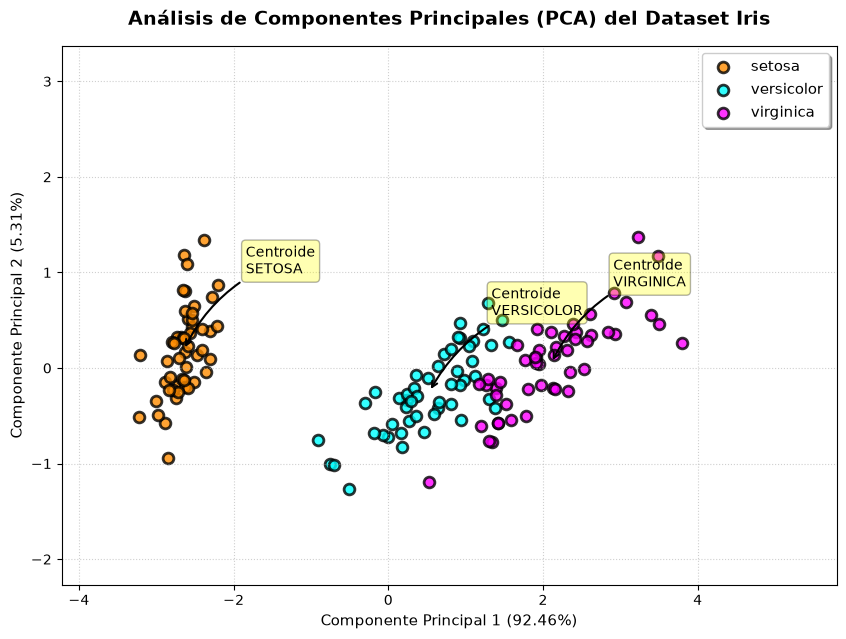

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# 1. Cargar datos de Iris y aplicar PCA
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

pca = PCA(n_components=2)
X_r = pca.fit_transform(X)

# 2. Configurar la figura con un estilo estilizado
plt.figure(figsize=(10, 7))
colors = ['darkorange', 'cyan', 'fuchsia']
lw = 2

# Dibujar los puntos correspondientes a cada clase
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    points = X_r[y == i]
    plt.scatter(points[:, 0], points[:, 1], color=color, alpha=.8, lw=lw,
                label=target_name, edgecolors='black', s=60)
    
    # Calcular el centroide de la clase para la anotación avanzada
    centroid = np.mean(points, axis=0)
    
    # 3. Añadir anotaciones avanzadas (Bocadillos y flechas personalizadas)
    plt.annotate(
        f'Centroide\n{target_name.upper()}',
        xy=(centroid[0], centroid[1]), 
        xytext=(centroid[0] + 0.8, centroid[1] + 0.8),
        textcoords='data',
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black', lw=1.5),
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3, ec="black")
    )

# 4. Personalización del fondo y ejes
plt.title('Análisis de Componentes Principales (PCA) del Dataset Iris', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=11)
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=11)

# Posicionar la leyenda de forma externa y elegante
plt.legend(loc='upper right', shadow=True, scatterpoints=1, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Ajustar límites para dar espacio a las anotaciones
plt.xlim(X_r[:,0].min() - 1, X_r[:,0].max() + 2)
plt.ylim(X_r[:,1].min() - 1, X_r[:,1].max() + 2)

plt.show()

### Matriz de Subgráficos Estructurada (plt.subplots)
Set de datos: Iris Dataset (Atributos de flores morfológicas)

En el análisis exploratorio de datos, a menudo necesitamos evaluar cómo se distribuyen las variables de forma independiente. Este ejemplo crea una cuadrícula de $2 \times 2$ subgráficos para mapear los histogramas y densidades estimadas por kernel (KDE approximation) de cada característica física del dataset.

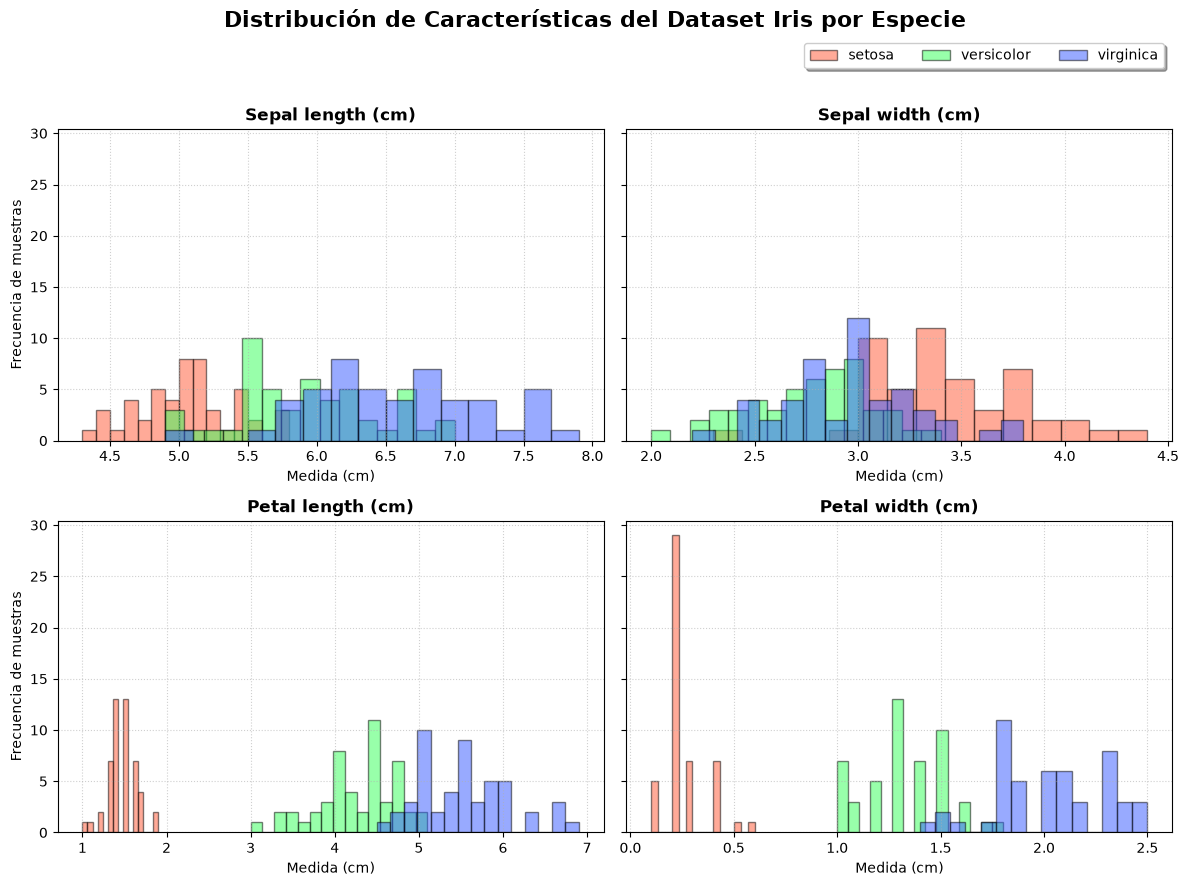

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

# 1. Cargar el dataset real
iris = load_iris()
X = iris.data
feature_names = iris.feature_names
target = iris.target
target_names = iris.target_names

# 2. Crear una figura compartiendo una estructura regular de subgráficos (2 filas, 2 columnas)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9), sharey=True)

# Lista de colores por cada clase de flor
colors = ['#FF5733', '#33FF57', '#3357FF']

# 3. Iterar dinámicamente sobre la matriz plana de subgráficos
for i, ax in enumerate(axs.flat):
    # Separar los datos de la característica actual por cada clase
    for class_idx, class_name in enumerate(target_names):
        subset = X[target == class_idx, i]
        
        # Dibujar el histograma en el subgráfico correspondiente
        ax.hist(subset, bins=15, alpha=0.5, label=class_name, color=colors[class_idx], edgecolor='black')
    
    # Personalización avanzada por cada subgráfico individual
    ax.set_title(feature_names[i].capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Medida (cm)', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Poner las etiquetas del eje Y solo en la primera columna para evitar redundancias
    if i % 2 == 0:
        ax.set_ylabel('Frecuencia de muestras', fontsize=10)

# 4. Ajustes globales de la figura
fig.suptitle('Distribución de Características del Dataset Iris por Especie', fontsize=16, fontweight='bold', y=0.98)

# Colocar una leyenda única global en lugar de repetirla en cada subgráfico
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.95), shadow=True, ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.93]) # Ajustar márgenes para que no se superpongan los textos
plt.show()

### Subgráficos Asimétricos y Dinámicos (GridSpec)
Set de datos: Diabetes Dataset (Evolución de la enfermedad frente a factores como IMC, presión sanguínea, etc.)

Este ejemplo avanzado utiliza una estructura no uniforme. El subgráfico de la izquierda abarca toda la altura de la cuadrícula y muestra una regresión lineal con intervalos simulados de confianza, mientras que la parte derecha se divide en dos subgráficos independientes para evaluar las variables asociadas a nivel estadístico (diagramas de caja y dispersión residual).

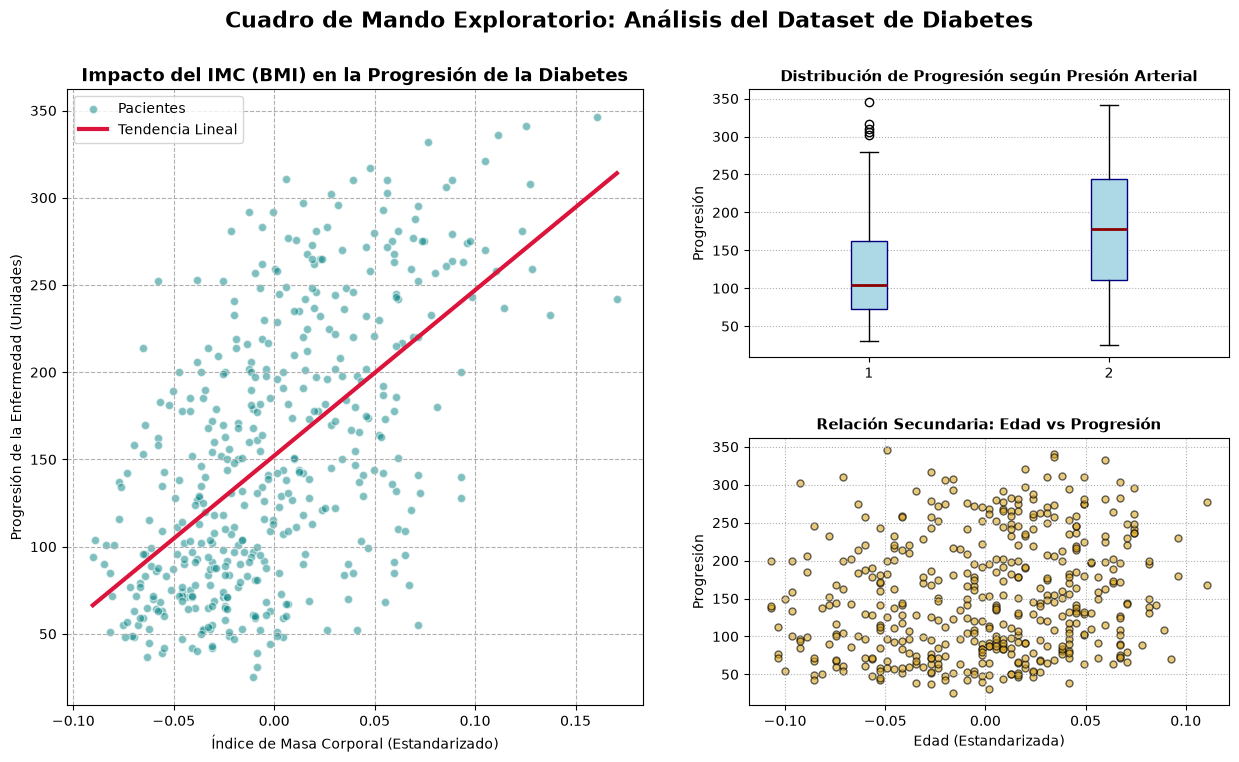

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# 1. Cargar y preparar datos
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Tomamos dos variables principales: BMI (Índice de Masa Corporal) y la progresión de la enfermedad (target)
X_bmi = df[['bmi']].values
y = df['target'].values

# Entrenar un regresor rápido para la visualización del modelo
model = LinearRegression().fit(X_bmi, y)
X_seq = np.linspace(X_bmi.min(), X_bmi.max(), 100).reshape(-1, 1)
y_pred = model.predict(X_seq)

# 2. Definir una estructura avanzada asimétrica usando GridSpec
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(nrows=2, ncols=2, width_ratios=[1.2, 1], hspace=0.3, wspace=0.2)

# Asignar posiciones
ax_main = fig.add_subplot(gs[:, 0])      # Columna 0 completa (Filas 0 y 1)
ax_top_right = fig.add_subplot(gs[0, 1]) # Fila 0, Columna 1
ax_bot_right = fig.add_subplot(gs[1, 1]) # Fila 1, Columna 1

# 3. Subgráfico Izquierdo (Principal): Ajuste de Regresión
ax_main.scatter(df['bmi'], df['target'], alpha=0.5, color='teal', edgecolors='w', label='Pacientes')
ax_main.plot(X_seq, y_pred, color='crimson', linewidth=3, label='Tendencia Lineal')
ax_main.set_title('Impacto del IMC (BMI) en la Progresión de la Diabetes', fontsize=13, fontweight='bold')
ax_main.set_xlabel('Índice de Masa Corporal (Estandarizado)')
ax_main.set_ylabel('Progresión de la Enfermedad (Unidades)')
ax_main.legend()
ax_main.grid(True, linestyle='--')

# 4. Subgráfico Superior Derecho: Diagrama de Caja Condicional (Categorización interna)
# Dividimos artificialmente a los pacientes en presión arterial (bp) alta y baja para el análisis visual
bp_median = df['bp'].median()
df['bp_group'] = np.where(df['bp'] >= bp_median, 'Presión Alta', 'Presión Baja')

box_data = [df[df['bp_group'] == 'Presión Baja']['target'], df[df['bp_group'] == 'Presión Alta']['target']]
ax_top_right.boxplot(box_data, patch_artist=True, label=['Presión Baja', 'Presión Alta'],
                     boxprops=dict(facecolor='lightblue', color='navy'),
                     medianprops=dict(color='darkred', linewidth=2))
ax_top_right.set_title('Distribución de Progresión según Presión Arterial', fontsize=11, fontweight='bold')
ax_top_right.set_ylabel('Progresión')
ax_top_right.grid(True, axis='y', linestyle=':')

# 5. Subgráfico Inferior Derecho: Gráfico de Dispersión Secundario (Edad vs Progresión)
ax_bot_right.scatter(df['age'], df['target'], alpha=0.6, color='goldenrod', edgecolors='k', s=25)
ax_bot_right.set_title('Relación Secundaria: Edad vs Progresión', fontsize=11, fontweight='bold')
ax_bot_right.set_xlabel('Edad (Estandarizada)')
ax_bot_right.set_ylabel('Progresión')
ax_bot_right.grid(True, linestyle=':')

# Título General Informativo
fig.suptitle('Cuadro de Mando Exploratorio: Análisis del Dataset de Diabetes', fontsize=16, fontweight='bold')

plt.show()